

<center>

# DBSCAN Clustering of Nairobi Health Facilities (Kenyan Real-World Dataset)

##### **Programme:** Master of Science in Artificial Intelligence
##### **Course:** CSA 806 - Data Mining and Big Data
##### **Module:** Module 7 Clustering
##### **Name:** Marrion Kiprop Cherop
##### **Reg Number:** ST62/80971/2024
</center>


## Introduction
This analysis applies **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** to a real-world Kenyan health dataset.

## Dataset used
The source dataset is **Health Facilities in Kenya**, published on openAFRICA. It contains facility-level records with administrative location details and service attributes.  
For this report, a cleaned subset of **operational facilities in Nairobi County** is used.

## Goal
- preprocess the data for DBSCAN
- tune **eps** and **min_samples**
- visualize clusters in 2D using PCA
- identify and interpret **noise points**
- derive actionable insights for health service planning


In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score



## 1. Load the cleaned Nairobi subset
The CSV file in this folder was prepared from the broader Kenyan health facilities dataset.


In [2]:

df = pd.read_csv('nairobi_health_facilities_dbscan_input.csv')
print(df.shape)
df.head()


(917, 19)


,Facility Code,Facility Name,County,District,Division,Type,Type_grouped,Owner,Beds,Cots,log_beds,log_cots,Open 24 Hours,Open Weekends,ART,C-IMCI,FP,HBC,IPD
0,19310,St Jude's Huruma Community Health Services,Nairobi,Mathare,Huruma,Medical Clinic,Medical Clinic,Private Practice - Unspecified,0.0,0.0,0.00000,0.0,0,1,0,0,0,0,0
1,13043,7Kr Mrs Health Centre,Nairobi,Langata,Lang'ata,Health Centre,Health Centre,Armed Forces,14.0,0.0,2.70805,0.0,1,1,0,1,1,1,1
2,20346,AAR Adams Health Centre,Nairobi,Kibra,Woodly,Medical Clinic,Medical Clinic,Private Practice - General Practitioner,0.0,0.0,0.00000,0.0,0,1,0,0,0,0,0
3,12861,AAR City Centre Clinic,Nairobi,Starehe,Starehe,Medical Clinic,Medical Clinic,Private Enterprise (Institution),0.0,0.0,0.00000,0.0,0,1,0,0,1,0,1
4,16796,AAR Clinic Sarit Centre (Westlands),Nairobi,Westlands,Parklands,Medical Clinic,Medical Clinic,Private Enterprise (Institution),0.0,0.0,0.00000,0.0,0,0,0,0,0,0,0



## 2. Quick exploration
We will cluster facilities using a mix of:
- capacity variables: `Beds`, `Cots`
- operational/service flags: `Open 24 Hours`, `Open Weekends`, `ART`, `C-IMCI`, `FP`, `HBC`, `IPD`
- facility type information through grouped categories

Because DBSCAN depends on distances, the features must be standardized.


In [3]:

feature_cols = [
    'log_beds', 'log_cots', 'Open 24 Hours', 'Open Weekends',
    'ART', 'C-IMCI', 'FP', 'HBC', 'IPD', 'Type_grouped'
]

X = pd.get_dummies(df[feature_cols], columns=['Type_grouped'], drop_first=False)
print('Feature matrix shape:', X.shape)
X.head()


Feature matrix shape: (917, 16)


,log_beds,log_cots,Open 24 Hours,Open Weekends,ART,C-IMCI,FP,HBC,IPD,Type_grouped_Dispensary,Type_grouped_Health Centre,Type_grouped_Medical Clinic,Type_grouped_Nursing Home,Type_grouped_Other,Type_grouped_Other Hospital,Type_grouped_VCT Centre (Stand-Alone)
0,0.00000,0.0,0,1,0,0,0,0,0,False,False,True,False,False,False,False
1,2.70805,0.0,1,1,0,1,1,1,1,False,True,False,False,False,False,False
2,0.00000,0.0,0,1,0,0,0,0,0,False,False,True,False,False,False,False
3,0.00000,0.0,0,1,0,0,1,0,1,False,False,True,False,False,False,False
4,0.00000,0.0,0,0,0,0,0,0,0,False,False,True,False,False,False,False


In [16]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use PCA for dimensionality reduction before DBSCAN.
# This speeds up the algorithm and helps with visualization.
pca_for_dbscan = PCA(n_components=3, random_state=42)
X_pca3 = pca_for_dbscan.fit_transform(X_scaled)

pca_vis = PCA(n_components=2, random_state=42)
X_pca2 = pca_vis.fit_transform(X_scaled)

print('Explained variance by 3 PCs:', pca_for_dbscan.explained_variance_ratio_.sum())
print('Explained variance by 2 PCs:', pca_vis.explained_variance_ratio_.sum())


Explained variance by 3 PCs: 0.4858572245702683
Explained variance by 2 PCs: 0.3990328665890742



## 3. Tune `eps` and `min_samples`
A full grid search is possible, but here we test a practical set of candidate values.

To compare settings, we look at:
- **number of clusters** (excluding noise)
- **noise ratio**
- **silhouette score** on non-noise points only

A very high silhouette with too many tiny clusters is not always ideal. We want a solution that is both statistically reasonable and easy to interpret.


In [5]:

def evaluate_dbscan(X_embedded, eps_values, min_samples_values):
    rows = []
    for eps in eps_values:
        for min_samples in min_samples_values:
            model = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=1)
            labels = model.fit_predict(X_embedded)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise_ratio = (labels == -1).mean()

            silhouette = np.nan
            mask = labels != -1
            if n_clusters >= 2 and len(set(labels[mask])) > 1:
                silhouette = silhouette_score(X_embedded[mask], labels[mask])

            rows.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'noise_ratio': noise_ratio,
                'silhouette_non_noise': silhouette
            })
    return pd.DataFrame(rows)

results = evaluate_dbscan(
    X_pca3,
    eps_values=[0.7, 0.8, 0.9, 1.0, 1.1],
    min_samples_values=[5, 8, 10, 12]
)

results.sort_values(['silhouette_non_noise', 'noise_ratio'], ascending=[False, True]).head(12)


,eps,min_samples,n_clusters,noise_ratio,silhouette_non_noise
3,0.7,12,15,0.183206,0.559001
2,0.7,10,16,0.146129,0.550834
7,0.8,12,13,0.130862,0.496383
1,0.7,8,13,0.128680,0.463019
6,0.8,10,12,0.119956,0.433863
0,0.7,5,19,0.073064,0.424717
10,0.9,10,5,0.095965,0.423053
9,0.9,8,5,0.085060,0.413856
11,0.9,12,6,0.107961,0.404768
5,0.8,8,11,0.102508,0.346905



## 4. Select final DBSCAN settings
For this, we choose:
- **eps = 0.9**
- **min_samples = 8**

This setting gives a useful balance:
- a manageable number of clusters
- a moderate amount of noise
- interpretable groups of facilities


In [6]:
final_dbscan = DBSCAN(eps=0.9, min_samples=8, n_jobs=1)
df["Cluster"] = final_dbscan.fit_predict(X_pca3)

cluster_counts = df["Cluster"].value_counts().sort_index()
noise_ratio = (df["Cluster"] == -1).mean()
num_clusters = len(set(df["Cluster"])) - (1 if -1 in df["Cluster"].values else 0)

print("Number of clusters:", num_clusters)
print("Noise ratio:", round(noise_ratio, 3))
print()
print("Cluster counts:")
print(cluster_counts)


Number of clusters: 5
Noise ratio: 0.085

Cluster counts:
Cluster
-1     78
 0    410
 1    266
 2     72
 3     76
 4     15
Name: count, dtype: int64



## 5. Visualize the clusters in 2D
The clustering is done on the 3-component PCA representation, but we visualize it using the first 2 principal components.

Points labeled **-1** are noise points.


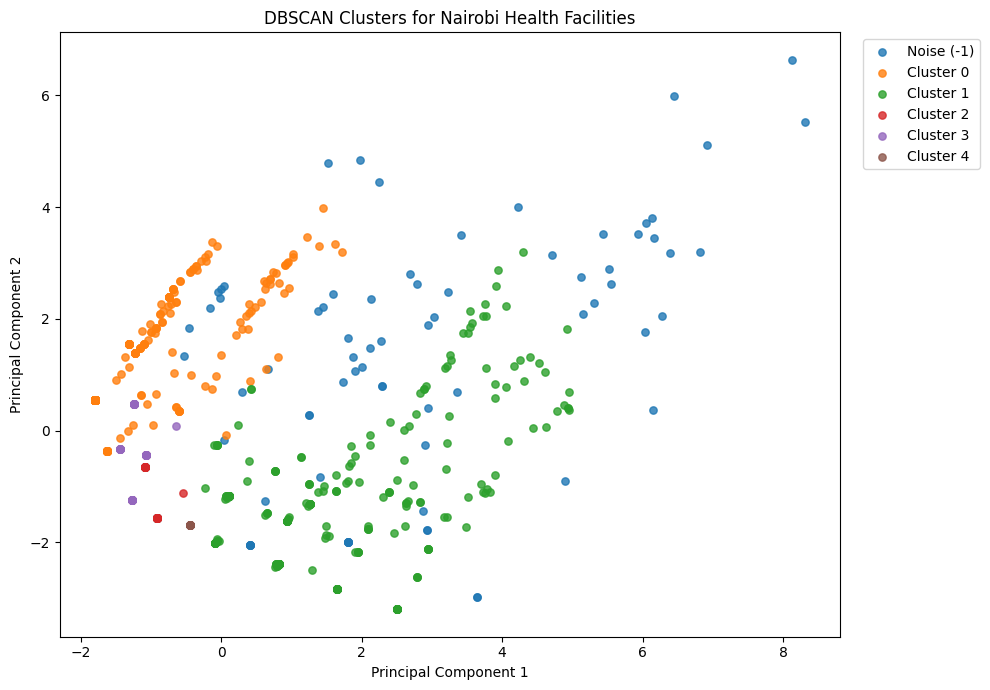

In [7]:

plot_df = pd.DataFrame({
    'PC1': X_pca2[:, 0],
    'PC2': X_pca2[:, 1],
    'Cluster': df['Cluster']
})

plt.figure(figsize=(10, 7))
for cluster_id in sorted(plot_df['Cluster'].unique()):
    mask = plot_df['Cluster'] == cluster_id
    label = 'Noise (-1)' if cluster_id == -1 else f'Cluster {cluster_id}'
    plt.scatter(plot_df.loc[mask, 'PC1'], plot_df.loc[mask, 'PC2'], s=28, alpha=0.8, label=label)

plt.title('DBSCAN Clusters for Nairobi Health Facilities')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


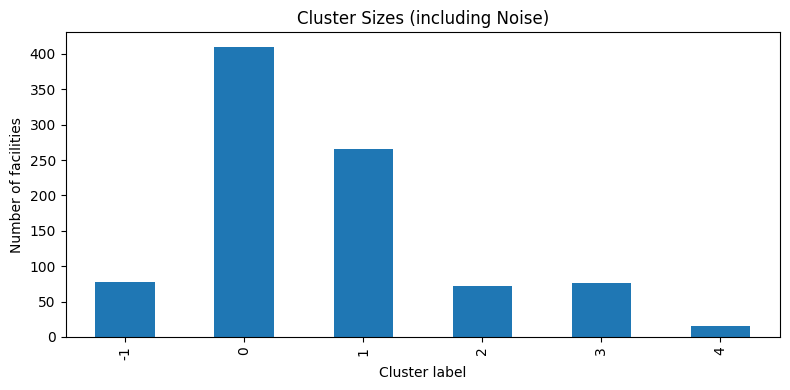

In [8]:

cluster_counts.plot(kind='bar', figsize=(8, 4))
plt.title('Cluster Sizes (including Noise)')
plt.xlabel('Cluster label')
plt.ylabel('Number of facilities')
plt.tight_layout()
plt.show()



## 6. Profile the clusters
We summarize each cluster using average service/capacity variables.


In [9]:

profile_cols = ['Beds', 'Cots', 'Open 24 Hours', 'Open Weekends', 'ART', 'C-IMCI', 'FP', 'HBC', 'IPD']
cluster_profile = df.groupby('Cluster')[profile_cols].mean().round(2)
cluster_profile


,Beds,Cots,Open 24 Hours,Open Weekends,ART,C-IMCI,FP,HBC,IPD
Cluster,,,,,,,,,
-1,71.17,11.12,0.65,0.67,0.47,0.35,0.64,0.71,0.68
0,1.96,0.37,0.25,0.81,0.00,0.00,0.00,0.00,0.00
1,3.47,0.18,0.17,0.25,0.27,0.17,0.83,0.65,0.88
2,0.04,0.00,0.00,0.36,0.00,0.00,0.00,0.00,0.00
3,0.05,0.00,0.00,0.39,0.00,0.00,0.00,0.00,0.00
4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00


In [10]:

type_profile = pd.crosstab(df['Cluster'], df['Type_grouped'])
type_profile


Type_grouped,Dispensary,Health Centre,Medical Clinic,Nursing Home,Other,Other Hospital,VCT Centre (Stand-Alone)
Cluster,,,,,,,
-1,3,4,18,6,23,16,8
0,8,28,362,6,0,6,0
1,107,56,68,13,2,18,2
2,72,0,0,0,0,0,0
3,0,0,0,0,47,0,29
4,0,0,0,0,0,0,15



## 7. Inspect the noise points
Noise points are not mistakes by default. In DBSCAN, noise can mean:
- very unusual facilities
- large hospitals with service profiles unlike most others
- specialized centres
- rare service combinations

These points can be analytically important.


In [11]:

noise_points = df[df['Cluster'] == -1].copy()
noise_points[['Facility Name', 'Type', 'Owner', 'Beds', 'Cots', 'Open 24 Hours', 'Open Weekends', 'ART', 'FP', 'HBC', 'IPD']].head(20)


,Facility Name,Type,Owner,Beds,Cots,Open 24 Hours,Open Weekends,ART,FP,HBC,IPD
10,Afwan Medical Centre,Nursing Home,Private Enterprise (Institution),40.0,4.0,1,1,0,1,0,1
16,Avenue Hospital,Other Hospital,Private Enterprise (Institution),65.0,10.0,1,1,0,1,1,1
29,St Jude's Medical Centre,Medical Clinic,Private Enterprise (Institution),0.0,0.0,1,1,0,1,1,1
39,The Karen Hospital,Other Hospital,Private Enterprise (Institution),102.0,0.0,1,1,0,1,1,1
43,The Mater Hospital Mukuru,Other Hospital,Kenya Episcopal Conference-Catholic Secretariat,166.0,42.0,1,1,1,0,1,1
66,Dandora (EDARP) Clinic,Medical Clinic,Kenya Episcopal Conference-Catholic Secretariat,0.0,0.0,0,0,1,1,1,1
92,Kemri VCT,VCT Centre (Stand-Alone),Ministry of Health,40.0,0.0,0,0,1,0,1,0
102,Liverpool VCT,VCT Centre (Stand-Alone),Non-Governmental Organizations,0.0,0.0,0,0,1,0,1,0
111,Maria Maternity and Nursing Home,Maternity Home,Private Practice - General Practitioner,20.0,4.0,0,0,0,1,1,1
113,Mariakani Cottage Hospital Ltd,Nursing Home,Private Enterprise (Institution),44.0,6.0,1,1,1,1,1,1



## 8. Interpretation
Based on the cluster summary we see these patterns:

- **Cluster 0:** mostly medical clinics with limited inpatient capacity and fewer advanced service flags
- **Cluster 1:** more service-rich facilities, often with FP, HBC and IPD present
- **Cluster 2:** small dispensaries with minimal bed capacity and limited service complexity
- **Cluster 3:** stand-alone VCT and other low-capacity specialized facilities
- **Cluster 4:** a small specialized group with very similar service signatures
- **Noise (-1):** unusually large or atypical facilities such as major hospitals, maternity facilities, or specialized centres

### Why the noise points matter
In this dataset, many noise points are not random outliers. They are often **high-capacity hospitals or rare facility types** that do not resemble the dense majority of small clinics and dispensaries. In planning terms, those facilities may represent:
- referral hubs
- high-pressure service nodes
- specialized facilities needing separate analysis rather than averaging them into the main clusters

## 9. Actionable insights
1. **Differentiate routine primary-care facilities from high-capacity hospitals.** They do not behave the same, and DBSCAN clearly separates them.
2. **Plan outreach by cluster type.** Small dispensaries and stand-alone centres may need different supply, staffing, and referral support than service-rich clinics.
3. **Treat noise points as strategic assets.** They may be major referral hospitals or rare specialized units and should be examined individually.
4. **Avoid one-size-fits-all resource allocation.** The clustering suggests that Nairobi's facilities are not homogeneous.
